# <center>**Dask pour le traitement des données**</center>

Le traitement des données, en particulier pour les grands jeux de données, nécessite des outils puissants. Dask et PySpark sont deux des outils les plus populaires de l'écosystème Python pour le traitement scalable des données. Dans ce notebook, nous allons explorer Dask, en vous fournissant des exemples pratiques et des réflexions sur quand et comment l'utiliser.

# **Requirements**

**Fichiers de données :** Aircraft_01.h5.zip, Aircraft_02.h5.zip, Aircraft_03.h5.zip, vol01.csv

# **Concepts de base**

### **1. Introduction**

**Qu'est-ce que Dask ?**

Dask est une bibliothèque de calcul parallèle flexible pour l'analyse des données, permettant aux utilisateurs d'exploiter toute la puissance de leur CPU et de leur mémoire sans avoir besoin d'un cluster.

**Caractéristiques principales :**

- Planification dynamique des tâches.
- S'intègre bien avec les bibliothèques Python populaires telles que Pandas et Numpy.
- Permet d'utiliser Dask DataFrame, qui est similaire à Pandas mais fonctionne sur des ensembles de données plus grands que la mémoire.

**Installer Dask :**

In [1]:
pip install dask[complete]

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install graphviz

Note: you may need to restart the kernel to use updated packages.


**Importer Dask :**

In [3]:
import os
os.chdir('TDs-statistiques-descriptives')

In [4]:
import dask.dataframe as dd

### **2. Dask Client et Ordonnanceurs (Schedulers)**

#### **Dask Client :**
Lorsque vous initialisez un `Client` sans arguments, cela met en place un cluster Dask local utilisant l'ordonnanceur distribué. Cela signifie que, même s'il est local (sur votre machine), il tire parti des avantages des capacités de calcul distribué de Dask. Voici deux scénarios différents d'utilisation de l'ordonnanceur distribué de Dask :
   
##### **Cluster Local (Machine unique) :**
Dans ce contexte, "distribué" ne signifie pas que les tâches sont réparties entre différentes machines, mais plutôt que les tâches peuvent être distribuées sur tous les cœurs ou threads de votre machine unique. Cela permet des fonctionnalités de parallélisme avancées, des calculs asynchrones et donne accès à un tableau de bord web pour des informations diagnostiques. C'est ce qui se passe lorsque vous utilisez `Client()` sans vous connecter à un cluster externe.

##### **Cluster Distribué (Plusieurs machines) :**
Dask peut être configuré pour fonctionner sur un cluster de plusieurs machines, où les calculs sont vraiment distribués sur différents nœuds du cluster. Ceci est utile pour des jeux de données très volumineux ou des tâches nécessitant beaucoup de calculs, où les ressources d'une seule machine seraient insuffisantes.

#### **Paramètres par défaut avec `Client()` :**
- **Ouvriers (Workers)** : Équivalent au nombre de cœurs physiques sur votre machine.
- **Threads par ouvrier** : 1 thread par défaut.
- **Limite de mémoire** : Une fraction de votre mémoire totale disponible est utilisée pour chaque ouvrier.

#### **Sans l'initialisation du Client :**
Dask utilise par défaut l'ordonnanceur à base de threads pour les opérations. Il s'agit d'un ordonnanceur interne utilisant un pool de threads de taille fixe. Cela signifie que vous n'utilisez pas les capacités distribuées, mais exécutez plutôt des calculs en parallèle en utilisant des threads sur votre machine locale.

#### **Ordonnanceurs :**
Dask prend en charge divers ordonnanceurs (à base de threads, multiprocessing, distribué). Le choix de l'ordonnanceur détermine comment Dask exécute les calculs parallèles. En utilisant un `Client`, vous optez pour l'ordonnanceur distribué, même si tous les calculs sont effectués uniquement sur votre machine locale.

En utilisant un `Client`, vous obtenez non seulement l'accès à l'ordonnanceur distribué, mais aussi à des outils supplémentaires comme le tableau de bord diagnostique de Dask, qui est utile pour surveiller et débuguer des calculs parallèles.

In [5]:
# Création sûre d'un client Dask dans Jupyter
import os
from dask.distributed import Client, default_client
try:
    _ = default_client()
    print('Un client Dask est déjà connecté.')
except Exception:
    n = os.cpu_count() or 2
    client = Client(n_workers=n, threads_per_worker=1)
    print('Client Dask créé avec', n, 'workers.')
client


Client Dask créé avec 8 workers.


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 8
Total threads: 8,Total memory: 6.32 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:45337,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:44775,Total threads: 1
Dashboard: http://127.0.0.1:37661/status,Memory: 808.48 MiB
Nanny: tcp://127.0.0.1:38693,


/home/cantez93800/.local/pipx/venvs/jupyterlab/lib/python3.11/site-packages/distributed/scheduler.py:6264: UserWarning: Scheduler already contains a plugin with name multi-progress-c27515ea3076944d16fb1c07e4adeb42; overwriting.
  warnings.warn(


### **3. Usage basique**

**Lire un fichier CSV :**

In [6]:
df = dd.read_csv('./data/vol01.csv')

**Les opérations sont paresseuses (elles ne sont pas calculées immédiatement)**

In [7]:
result = df.groupby('ALT [ft]').mean()

**Calculer le résultat :**

In [8]:
result.compute()

,EGT_1 [deg C],EGT_2 [deg C],FMV_1 [mm],FMV_2 [mm],HPTACC_1 [%],HPTACC_2 [%],M [Mach],N1_1 [% rpm],N1_2 [% rpm],N2_1 [% rpm],...,VIB_AN1_1 [mils],VIB_AN1_2 [mils],VIB_AN2_1 [ips],VIB_AN2_2 [ips],VIB_BN1_1 [mils],VIB_BN1_2 [mils],VIB_BN2_1 [ips],VIB_BN2_2 [ips],VSV_1 [mm],VSV_2 [mm]
ALT [ft],,,,,,,,,,,,,,,,,,,,,
-23.183203,624.089720,646.255495,4.184419,4.167181,3.955259,34.638180,0.000000,23.638659,23.268110,54.129175,...,0.072908,0.000000,0.000000,0.255179,0.072908,0.000000,0.000000,0.255179,54.841671,54.904192
-18.546562,522.915270,629.356460,3.721907,4.281759,13.576883,34.436766,0.000000,20.930621,23.371085,47.964212,...,0.063935,0.007852,0.000000,0.215360,0.038137,0.007852,0.016264,0.235550,54.722880,54.625251
-13.909922,455.030296,604.080006,3.340158,4.318302,18.761545,34.371200,0.000000,18.924909,23.482675,42.733648,...,0.025414,0.004583,0.026664,0.180813,0.020831,0.002916,0.018331,0.218100,54.650832,54.309286
-9.273281,459.165128,515.484695,3.519823,3.805518,18.757023,33.914843,0.000797,20.859828,21.854212,43.861708,...,0.035070,0.009229,0.019842,0.157507,0.037223,0.017535,0.021534,0.259794,53.792965,53.728201
-4.636641,151.221978,167.811658,0.664343,0.761684,9.812895,34.463276,0.000818,7.567465,7.771416,12.989454,...,0.030615,0.011362,0.003314,0.039768,0.045765,0.019884,0.007101,0.082061,54.843205,54.842708
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39420.717939,673.867921,673.967144,9.430265,9.448990,89.403080,98.857785,0.637469,101.819794,101.913563,80.391251,...,1.464987,0.163126,0.043011,0.014424,2.405977,1.091528,0.079989,0.127983,9.043635,8.363996
39425.354580,677.533867,678.365084,9.499597,9.533730,89.571474,98.847483,0.637688,102.516471,102.669763,80.599093,...,1.534494,0.150374,0.043859,0.015949,2.507365,1.172230,0.084300,0.118476,8.699101,8.066561
39429.991220,675.734082,676.188765,9.460387,9.497088,85.362855,98.886037,0.637105,102.185496,102.268745,80.431121,...,1.441343,0.151425,0.053279,0.014021,2.445236,1.144101,0.067300,0.123383,8.617530,7.927390


**Filtrage des données :**

In [9]:
filtered_data = df[df['ALT [ft]'] > 1000].compute()

**Jointure des données :**

In [10]:
df1 = df[df['ALT [ft]'] > 1000]
df2 = df[df['ALT [ft]'] < 1500]
joined_data = df1.merge(df2, on='ALT [ft]').compute()

**Barre de progression avec le scheduler distribué :**

In [11]:
from dask.distributed import progress

# Lire CSV
df_dask = dd.read_csv('./data/vol01.csv')

# Filter, GroupBy and Calculer la moyenne (mean)
result_dask = df_dask[df_dask['ALT [ft]'] > 1500].groupby('ALT [ft]')["M [Mach]"].mean()

# Calculer le résultat
result_dask = result_dask.persist()

progress(result_dask)

VBox()

**Barre de progression sur un scheduler à machine unique (Vous ne verrez pas la barre de progression si avez initialisez le Client) :**

In [12]:
from dask.diagnostics import ProgressBar

with ProgressBar():
    # Lire CSV
    df_dask = dd.read_csv('./data/vol01.csv')

    # Filter, GroupBy and Calculer la moyenne (mean)
    result_dask = df_dask[df_dask['ALT [ft]'] > 1500].groupby('ALT [ft]')["M [Mach]"].mean()

    # Calculer le résultat
    result_dask = result_dask.persist()

progress(result_dask)

VBox()

### **4. Dask Delayed**

**Qu'est-ce que Dask Delayed ?**

Dask Delayed est un décorateur et une fonction. Il "retarde" l'exécution d'une fonction, au lieu de l'exécuter immédiatement. Lorsqu'une fonction est retardée, elle n'est pas encore calculée. Au lieu de cela, une représentation symbolique (ou tâche) du calcul est créée. Ces calculs symboliques peuvent ensuite être exécutés en parallèle.

**Comment ça marche?**

- Envelopper les calculs : En enveloppant les fonctions ou les calculs avec delayed, vous indiquez à Dask de ne pas les exécuter et de garder une trace des tâches pour un calcul parallèle ultérieur.

- Construire des graphes de tâches : Dask construit en interne un graphique de tâches à partir de ces opérations différées. Un graphique de tâches est une représentation visuelle de la séquence et des dépendances des opérations.

- Exécution parallèle : Une fois que votre calcul entier est construit en utilisant des fonctions retardées, vous pouvez calculer le résultat en parallèle en appelant la méthode `.compute()`.

**Pourquoi utiliser Delayed ?**

1. Algorithmes parallèles personnalisés : Bien que Dask fournisse des équivalents parallèles prêts à l'emploi pour de nombreuses opérations Python, Pandas et Numpy standard (comme Dask Array ou Dask DataFrame), vous pouvez rencontrer des scénarios dans lesquels vous avez besoin d'un parallélisme plus personnalisé. Dask Delayed vous permet de concevoir vos algorithmes parallèles sans avoir à vous plonger dans les complexités de la programmation parallèle.

2. Flexibilité : Vous pouvez combiner des collections Dask (comme Dask Array ou DataFrame) avec des fonctions retardées, ce qui offre un environnement flexible pour construire des pipelines complexes.

**Voyons un exemple:**

In [13]:
from dask import delayed

# Quelques fonctions simples
def inc(x):
    return x + 1

def add(x, y):
    return x + y

# Sans delayed
result = add(inc(1), inc(2))
print(result)  # Output: 5

5


**Maintenant, utilisons delayed:**

In [14]:
# Avec delayed
inc_delayed = delayed(inc)
add_delayed = delayed(add)

# Ils ne calculent pas encore le résultat, mais construisent le graphe de calcul.
a = inc_delayed(1)
b = inc_delayed(2)
result_delayed = add_delayed(a, b)

# Calcul en parallèle (dans ce cas simple, il n'y a pas grand-chose à paralléliser)
result = result_delayed.compute()
print(result)  # Output: 5

5


**Lorsque vous retardez une fonction (delayed), elle ne calcule pas immédiatement son résultat. Au lieu de cela, elle garde une trace du calcul dans un graphe de tâches, que vous pouvez visualiser:**

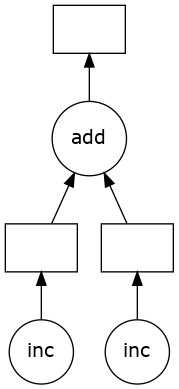

In [15]:
result_delayed.visualize()

# **Exercices**

## **Exercice 1 : Extraction de fichiers Zip**

### **Objectif :** 
Écrire une fonction qui extrait tous les fichiers ZIP d'un répertoire source vers un répertoire de destination.

#### **Consignes :**

- La fonction doit être nommée extraire_fichiers_zip.
- La fonction doit accepter deux arguments :
    - repertoire_source : Le répertoire dans lequel rechercher les fichiers ZIP.
    - repertoire_destination : Le répertoire où les fichiers ZIP doivent être extraits.
- Si le répertoire de destination n'existe pas, la fonction doit le créer.
- Après l'extraction de chaque fichier ZIP, affichez un message informant l'utilisateur que le fichier a été extrait avec succès.

#### **Bonus :**

- Gérez les exceptions potentielles qui pourraient survenir lors de l'ouverture de fichiers ZIP corrompus.
- Créez une fonction de logs pour enregistrer chaque action réalisée (par exemple, la création d'un répertoire, l'extraction réussie d'un fichier, etc.).

#### **Astuces :**

- Utilisez le module os pour interagir avec le système de fichiers.
- Le module zipfile vous sera très utile pour gérer les fichiers ZIP.


Bonne chance !

In [16]:
import pandas as pd
import numpy as np
import zipfile, os
import dask.dataframe as dd
from datetime import datetime

In [17]:
os.listdir()

['.git',
 'TD1',
 'TD2',
 'TD3',
 'TD4',
 'TD5',
 'data',
 'mydask.png',
 'journal_extraction.log',
 'ddf_temp.pkl']

In [18]:
def ecrire_log(message, fichier_log="journal_extraction.log"):
    """Enregistre un message dans le fichier de log avec un horodatage."""
    horodatage = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    with open(fichier_log, "a", encoding="utf-8") as f:
        f.write(f"[{horodatage}] {message}\n")


def extraire_fichiers_zip(repertoire_source, repertoire_destination):
    """
    Extrait tous les fichiers zip du répertoire source vers le répertoire de destination.

    Paramètres:
    - repertoire_source (str): Le répertoire dans lequel rechercher les fichiers zip.
    - repertoire_destination (str): Le répertoire où les fichiers zip doivent être extraits.

    Retourne:
    - None
    """

    # Vérifier que le répertoire source existe
    if not os.path.exists(repertoire_source):
        message = f"Erreur : Le répertoire source '{repertoire_source}' n'existe pas."
        print(message)
        ecrire_log(message)
        return

    # Créer le répertoire de destination s’il n’existe pas
    if not os.path.exists(repertoire_destination):
        os.makedirs(repertoire_destination)
        message = f"Création du répertoire de destination : {repertoire_destination}"
        print(message)
        ecrire_log(message)

    # Lister les fichiers ZIP
    fichiers_zip = [f for f in os.listdir(repertoire_source) if f.lower().endswith(".zip")]
    if not fichiers_zip:
        message = "Aucun fichier ZIP trouvé dans le répertoire source."
        print(message)
        ecrire_log(message)
        return

    # Parcourir chaque fichier ZIP
    for fichier in fichiers_zip:
        chemin_zip = os.path.join(repertoire_source, fichier)
        try:
            with zipfile.ZipFile(chemin_zip, 'r') as zip_ref:
                zip_ref.extractall(repertoire_destination)
            message = f"Extraction réussie du fichier : {fichier}"
            print(message)
            ecrire_log(message)
        except zipfile.BadZipFile:
            message = f"Erreur : Le fichier '{fichier}' est corrompu et n’a pas pu être extrait."
            print(message)
            ecrire_log(message)
        except Exception as e:
            message = f"Erreur inattendue lors de l’extraction de '{fichier}' : {e}"
            print(message)
            ecrire_log(message)

    print("Extraction terminée pour tous les fichiers ZIP.")
    ecrire_log("Extraction terminée pour tous les fichiers ZIP.\n")

    ...

# Définir le répertoire où les fichiers zip sont stockés
repertoire_source = './data/data_zip'

# Définir le répertoire où les fichiers doivent être extraits
repertoire_destination = './data/data_extracted'

# Print la liste des fichiers dans le répertoire source
print("Fichiers dans repertoire_source:", os.listdir(repertoire_source))

# Appelez la fonction pour extraire tous les fichiers zip du source vers le répertoire de destination
extraire_fichiers_zip(repertoire_source, repertoire_destination)

# Print la liste des fichiers dans le répertoire de destination après extraction
print("Fichiers dans repertoire_destination après extraction:", os.listdir(repertoire_destination))

Fichiers dans repertoire_source: ['Aircraft_02.h5.zip', 'Aircraft_01.h5.zip', 'Aircraft_03.h5.zip']
Extraction réussie du fichier : Aircraft_02.h5.zip
Extraction réussie du fichier : Aircraft_01.h5.zip
Extraction réussie du fichier : Aircraft_03.h5.zip
Extraction terminée pour tous les fichiers ZIP.
Fichiers dans repertoire_destination après extraction: ['Aircraft_02.h5', 'Aircraft_01.h5', 'Aircraft_03.h5']


## **Exercice 2 : Lecture d'un fichier HDF5 avec Dask**

Lisez le fichier HDF5 du premier avion "Aircraft 01" à l'aide de la fonction `read_hdf` de Dask.

In [18]:
pip install tables

Note: you may need to restart the kernel to use updated packages.


In [20]:
nom_du_fichier = 'Aircraft_01.h5'
chemin_fichier = os.path.join(repertoire_destination, nom_du_fichier)
ddf = dd.read_hdf(chemin_fichier,'*')

TypeError: An error occurred while calling the read_hdf method registered to the pandas backend.
Original Message: 
This HDFStore is not partitionable and can only be use monolithically with
pandas.  In the future when creating HDFStores use the ``format='table'``
option to ensure that your dataset can be parallelized

### **L'Erreur**

Lors de la tentative de lecture d'un fichier HDF5 stocké au format fixe à l'aide de la fonction `read_hdf` de Dask, vous pourriez rencontrer l'erreur ci-dessus.
Cette erreur indique que le fichier HDF5 est dans un format qui ne lui permet pas d'être facilement partitionné pour un traitement parallèle par Dask.


### **Pourquoi?**

HDF5 est un format de stockage de données populaire capable de stocker de grands ensembles de données. Au sein du format HDF5, il existe deux principales façons de stocker des données :

1. **Format Fixe** : C'est le format de stockage par défaut dans lequel les données sont stockées sous forme de bloc monolithique.
2. **Format Tableau** : Dans ce format, les données sont stockées par morceaux, ce qui les rend essentiellement "partitionnées" et adaptées au traitement hors-mémoire et parallèle.

Dask est une bibliothèque de calcul parallèle qui permet des opérations efficaces sur de grands ensembles de données en travaillant simultanément sur de petits morceaux ou partitions. Lors de la tentative de lecture d'un fichier HDF5 avec Dask, si les données sont stockées au format fixe, cela peut conduire à des inefficacités et des erreurs potentielles car le fichier n'est pas intrinsèquement partitionné.



### **Objectif**

- Votre tâche est d'écrire une fonction capable de gérer cette erreur. La fonction devrait :

    1. Essayer de lire le fichier HDF5 à l'aide de Dask.
    2. S'il rencontre l'erreur mentionnée ci-dessus, il devrait créer une version partitionnée du fichier au format `tableau` et la stocker dans un dossier "data_dask".
    3. Une fois la version partitionnée créée, elle devrait lire cette version à l'aide de Dask et renvoyer le DataFrame Dask résultant.

### **Bonus**

- Améliorez la fonction pour vérifier d'abord si une version partitionnée du fichier existe déjà, et si c'est le cas, lisez cette version directement sans essayer de lire le fichier non partitionné.

### **Astuce**

- N'oubliez pas d'utiliser l'argument format='table' lors de la création d'une version partitionnée du fichier HDF5 avec pandas.

Bonne chance !


In [18]:
import os
import math
import h5py
import pandas as pd
import dask.dataframe as dd

def lire_hdf_dask(nom_fichier, repertoire='data/data_extracted', 
                  dossier_dask='data/data_dask', chunk_rows=10000):
    """
    Charge un fichier HDF5 dans un DataFrame Dask.

    Comportement :
    - Tente d'abord dd.read_hdf(chemin_source, key="*").
    - Si cela lève l'erreur "not partitionable" (format fixed), crée une version
      partitionnée au format 'table' en streaming (dans dossier_dask) puis la lit.
    - Si une version partitionnée existe déjà, la charge directement.

    Paramètres:
    - nom_fichier (str): Nom du fichier HDF5 (ex: 'Aircraft_01.h5').
    - repertoire (str): Répertoire où se trouve le fichier source.
    - dossier_dask (str): Répertoire où sera écrite la version partitionnée.
    - chunk_rows (int): nombre de lignes à écrire par chunk (ajuster selon RAM).

    Retour:
    - ddf: DataFrame Dask
    """

    # Chemins
    chemin_source = os.path.join(repertoire, nom_fichier)
    os.makedirs(dossier_dask, exist_ok=True)
    base, ext = os.path.splitext(nom_fichier)
    nom_partitionne = f"{base}_table{ext}"
    chemin_partitionne = os.path.join(dossier_dask, nom_partitionne)

    # 1) Si déjà partitionné -> charger et retourner
    if os.path.exists(chemin_partitionne):
        return dd.read_hdf(chemin_partitionne, key="data")

    # 2) Essayer de lire directement avec Dask (cas idéal)
    try:
        return dd.read_hdf(chemin_source, key="*")
    except TypeError as e:
        # Message attendu quand HDFStore est en format fixed
        msg = str(e)
        if ("not partitionable" not in msg) and ("This HDFStore is not partitionable" not in msg):
            # Si l'erreur n'est pas celle que l'on attend, remonter
            raise

    # 3) Ici : le fichier n'est pas partitionnable — on crée une version 'table'
    #    On parcourt les groupes record_* et on écrit par morceaux en mode append.
    with h5py.File(chemin_source, "r") as f:
        groupes = sorted(list(f.keys()))
        if len(groupes) == 0:
            raise ValueError("Fichier HDF5 vide ou aucune clé détectée.")

        # Déterminer colonnes à partir du premier groupe (axis0 / block0_items)
        premier = groupes[0]
        grp0 = f[premier]
        # choix robuste : axis0 si présent sinon block0_items
        if "axis0" in grp0:
            raw_cols = grp0["axis0"][()]
        elif "block0_items" in grp0:
            raw_cols = grp0["block0_items"][()]
        else:
            raise ValueError("Impossible de détecter les noms de colonnes dans le HDF5 (axis0 / block0_items absent).")
        # décodage si bytes
        cols = [c.decode() if isinstance(c, (bytes, bytearray)) else str(c) for c in raw_cols]

    # Écrire en streaming : pour chaque groupe, lire block0_values par morceaux et append dans le HDFStore
    # Supprimer fichier partitionné partiel s'il existe par sécurité (évite append incohérent)
    if os.path.exists(chemin_partitionne):
        try:
            os.remove(chemin_partitionne)
        except OSError:
            pass

    # Itérer groupes et écrire
    with h5py.File(chemin_source, "r") as f:
        for gname in groupes:
            grp = f[gname]
            if "block0_values" not in grp:
                # si le groupe ne contient pas le dataset attendu, on l'ignore
                continue
            dset = grp["block0_values"]
            nrows = dset.shape[0]

            # parcourir par chunks pour ne pas charger tout en RAM
            for start in range(0, nrows, chunk_rows):
                end = min(start + chunk_rows, nrows)
                arr = dset[start:end, :]  # slice numpy (ne charge que le chunk)
                # construire DataFrame et écrire (append=True)
                df_chunk = pd.DataFrame(arr, columns=cols)
                # Si première écriture, to_hdf crée le fichier, sinon append
                df_chunk.to_hdf(
                    chemin_partitionne,
                    key="data",
                    format="table",
                    append=True,
                    complevel=0,  # changer compression si souhaité
                )

    # 4) Lecture de la nouvelle version partitionnée avec Dask
    ddf = dd.read_hdf(chemin_partitionne, key="data")
    return ddf


# Testez la fonction
nom_du_fichier = 'Aircraft_01.h5'
ddf = lire_hdf_dask(nom_du_fichier)
print(f"DataFrame Dask du fichier {nom_du_fichier} a été chargé dans 'ddf'.")


DataFrame Dask du fichier Aircraft_01.h5 a été chargé dans 'ddf'.


## **Exercice 3 : Exploration de Dask DataFrame**

Dans cet exercice, vous allez explorer les caractéristiques et les propriétés de base d'un Dask DataFrame (ddf). L'objectif est de vous familiariser avec les composants clés et les méthodes associées à un Dask DataFrame.

### **Objectifs :**

1. **Nombre de Partitions** : 
   - Déterminez combien de partitions sont présentes dans le Dask DataFrame `ddf`.

2. **Noms des Indices** : 
   - Utilisez la méthode `map_partitions` pour obtenir le nom des indices de chaque partition de `ddf`.
   - Affichez les 10 premiers noms d'index.
   - Comptez le nombre total de noms d'index que vous avez récupérés.

3. **Colonnes du DataFrame** :
   - Récupérez toutes les colonnes de `ddf` et stockez-les dans une variable.
   - Comptez le nombre de colonnes.

4. **Types de Données** :
   - Examinez les types de données de chaque colonne dans `ddf`.

5. **Aperçu d'une Partition** :
   - Affichez les premières lignes de la première partition de `ddf`.

### **Astuces :**

- La méthode `map_partitions` peut être utilisée pour appliquer une fonction à chaque partition d'un Dask DataFrame.
- La méthode `compute()` force l'évaluation d'une opération Dask. Souvenez-vous que Dask est paresseux par défaut, c'est-à-dire qu'il ne calcule pas les résultats tant que vous ne le lui demandez pas.
- Vous pouvez accéder à une partition spécifique en utilisant `ddf.partitions[index]`.

### **Bonus :**

- Essayez d'afficher les dernières lignes de la dernière partition de `ddf`.
- Explorez d'autres méthodes et propriétés associées à `ddf` pour obtenir une meilleure compréhension de vos données.

Bonne chance !

In [19]:
import warnings
import pandas as pd
import dask
import dask.dataframe as dd
from dask.distributed import default_client
from IPython.display import display

SCHED = "synchronous"

# ---------------------------
# 0) Vérifier/normaliser ddf
# ---------------------------
if "ddf" not in globals():
    raise RuntimeError("La variable `ddf` n'existe pas dans l'environnement. Chargez ddf avant d'exécuter cette cellule.")

# Si l'utilisateur a un pandas.DataFrame par mégarde, on le convertit en Dask (1 partition par défaut)
if isinstance(ddf, pd.DataFrame):
    print("Objet `ddf` est un pandas.DataFrame — conversion automatique en Dask DataFrame (1 partition).")
    ddf = dd.from_pandas(ddf, npartitions=1)
elif not isinstance(ddf, dd.DataFrame):
    raise TypeError("`ddf` doit être soit un dask.dataframe.DataFrame soit un pandas.DataFrame.")

# Si aucune partition (npartitions n'est pas défini ou 0), on gère proprement
if getattr(ddf, "npartitions", 0) == 0:
    raise RuntimeError("Le Dask DataFrame a 0 partition (invalide). Vérifiez la source de ddf.")

# ---------------------------
# Fonctions utilitaires robustes
# ---------------------------
def _index_name_series(df):
    """
    Retourne une pandas.Series contenant exactement une cellule : df.index.name
    (map_partitions attend un DataFrame/Series, pas un scalaire)
    """
    return pd.Series([df.index.name])

# Meta pour map_partitions (type object pour noms d'index éventuels None/str)
META_INDEX_SER = pd.Series(dtype="object")


**1. Nombre de Partitions :**

In [20]:
# ---------------------------
# 1) Nombre de partitions
# ---------------------------
nb_partitions = ddf.npartitions
print("1) Nombre de partitions :", nb_partitions)

1) Nombre de partitions : 8


**2. Noms des Indices :**

In [21]:
# ---------------------------
# 2) Noms des indices via map_partitions (sûr et synchrone)
# ---------------------------
# On protège la computation avec try/except pour éviter plantage brutal.
try:
    index_names_series = ddf.map_partitions(
        _index_name_series,
        meta=META_INDEX_SER
    ).compute(scheduler=SCHED)
    # index_names_series est une Series avec une ligne par partition
    index_names = list(index_names_series.astype(object))  # forcer Python objects
    print("\n2) Noms des indices (extraites par partition) — 10 premiers :")
    print(index_names[:10])
    print("Nombre total de noms récupérés :", len(index_names))
except Exception as e:
    # En cas de problème on propose une fallback partition par partition (séquentiel)
    warnings.warn(f"map_partitions a échoué avec erreur: {e}. Tentative fallback (séquentiel par partition).", RuntimeWarning)
    index_names = []
    for i in range(nb_partitions):
        try:
            part_df = ddf.partitions[i].compute(scheduler=SCHED)
            index_names.append(part_df.index.name)
        except Exception as e2:
            index_names.append(None)
            warnings.warn(f"Impossible de lire partition {i} : {e2}", RuntimeWarning)
    print("\n2) (fallback) Noms des indices — 10 premiers :")
    print(index_names[:10])
    print("Nombre total de noms récupérés :", len(index_names))



2) Noms des indices (extraites par partition) — 10 premiers :
[None, None, None, None, None, None, None, None]
Nombre total de noms récupérés : 8


**3. Colonnes du DataFrame :**

In [22]:
# ---------------------------
# 3) Colonnes du DataFrame + nombre
# ---------------------------
# ddf.columns est une Index ; on convertit en list pour l'affichage
try:
    colonnes = list(ddf.columns)
    print("\n3) Colonnes du DataFrame (liste) — premières 20 affichées :")
    print(colonnes[:20])
    print("Nombre total de colonnes :", len(colonnes))
except Exception as e:
    raise RuntimeError(f"Échec lors de la lecture des colonnes : {e}")



3) Colonnes du DataFrame (liste) — premières 20 affichées :
['ALT [ft]', 'EGT_1 [deg C]', 'EGT_2 [deg C]', 'FMV_1 [mm]', 'FMV_2 [mm]', 'HPTACC_1 [%]', 'HPTACC_2 [%]', 'M [Mach]', 'N1_1 [% rpm]', 'N1_2 [% rpm]', 'N2_1 [% rpm]', 'N2_2 [% rpm]', 'NAIV_1 [bool]', 'NAIV_2 [bool]', 'P0_1 [psia]', 'P0_2 [psia]', 'PRV_1 [bool]', 'PRV_2 [bool]', 'PS3_1 [psia]', 'PS3_2 [psia]']
Nombre total de colonnes : 55


**4. Types de Données :**

In [23]:
# ---------------------------
# 4) Types de données de chaque colonne
# ---------------------------
# ddf.dtypes est un Series pandas-like accessible sans compute
try:
    dtypes = ddf.dtypes
    print("\n4) Types de données (dtypes) :")
    display(dtypes)
except Exception as e:
    raise RuntimeError(f"Échec lors de la lecture des dtypes : {e}")



4) Types de données (dtypes) :


ALT [ft]            float64
EGT_1 [deg C]       float64
EGT_2 [deg C]       float64
FMV_1 [mm]          float64
FMV_2 [mm]          float64
HPTACC_1 [%]        float64
HPTACC_2 [%]        float64
M [Mach]            float64
N1_1 [% rpm]        float64
N1_2 [% rpm]        float64
N2_1 [% rpm]        float64
N2_2 [% rpm]        float64
NAIV_1 [bool]       float64
NAIV_2 [bool]       float64
P0_1 [psia]         float64
P0_2 [psia]         float64
PRV_1 [bool]        float64
PRV_2 [bool]        float64
PS3_1 [psia]        float64
PS3_2 [psia]        float64
PT2_1 [mbar]        float64
PT2_2 [mbar]        float64
P_OIL_1 [psi]       float64
P_OIL_2 [psi]       float64
Q_1 [lb/h]          float64
Q_2 [lb/h]          float64
T1_1 [deg C]        float64
T1_2 [deg C]        float64
T2_1 [deg C]        float64
T2_2 [deg C]        float64
T3_1 [deg C]        float64
T3_2 [deg C]        float64
T5_1 [deg C]        float64
T5_2 [deg C]        float64
TAT [deg C]         float64
TBV_1 [%]           

**5. Aperçu d'une Partition :**

In [24]:
# ---------------------------
# 5) Aperçu de la première partition
# ---------------------------
try:
    # on récupère la première partition de façon synchrone et sûre
    first_partition_df = ddf.partitions[0].compute(scheduler=SCHED)
    print("\n5) Aperçu (head) de la première partition :")
    display(first_partition_df.head())
except Exception as e:
    warnings.warn(f"Impossible d'obtenir la première partition : {e}", RuntimeWarning)
    first_partition_df = None


5) Aperçu (head) de la première partition :


,ALT [ft],EGT_1 [deg C],EGT_2 [deg C],FMV_1 [mm],FMV_2 [mm],HPTACC_1 [%],HPTACC_2 [%],M [Mach],N1_1 [% rpm],N1_2 [% rpm],...,VIB_AN1_1 [mils],VIB_AN1_2 [mils],VIB_AN2_1 [ips],VIB_AN2_2 [ips],VIB_BN1_1 [mils],VIB_BN1_2 [mils],VIB_BN2_1 [ips],VIB_BN2_2 [ips],VSV_1 [mm],VSV_2 [mm]
0,-4.636641,33.494949,33.494949,-0.64553,-0.64913,4.637541,34.737062,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,56.59227,56.529748
1,-4.636641,33.494949,33.494949,-0.64553,-0.64913,4.637541,34.737062,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,56.59227,56.529748
2,-4.636641,33.494949,33.494949,-0.64553,-0.64913,4.696870,34.737062,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,56.59227,56.592270
3,-4.636641,33.494949,33.494949,-0.64553,-0.64913,4.696870,34.737062,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,56.59227,56.529748
4,-4.636641,33.494949,33.494949,-0.64553,-0.64913,4.696870,34.737062,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,56.59227,56.529748


In [25]:
# ---------------------------
# BONUS : dernières lignes de la dernière partition (si demandé)
# ---------------------------
try:
    last_idx = nb_partitions - 1
    last_partition_df = ddf.partitions[last_idx].compute(scheduler=SCHED)
    print(f"\nBonus) Dernières lignes de la dernière partition (partition {last_idx}) :")
    display(last_partition_df.tail())
except Exception as e:
    warnings.warn(f"Impossible d'obtenir la dernière partition : {e}", RuntimeWarning)
    last_partition_df = None

# ---------------------------
# Résumé final (retourner/afficher les objets utiles)
# ---------------------------
result = {
    "npartitions": nb_partitions,
    "index_names": index_names,          # liste Python (len = npartitions)
    "columns": colonnes,                 # liste de colonnes
    "ncolumns": len(colonnes),
    "dtypes": dtypes,                    # Series dtypes (pandas-like)
    "first_partition_df": first_partition_df,
    "last_partition_df": last_partition_df
}

print("\n✓ Exercice 3 exécuté sans erreur (si des warnings apparaissent, elles sont capturées).")
# Vous pouvez accéder au résumé via la variable `result`.
result


Bonus) Dernières lignes de la dernière partition (partition 7) :


,ALT [ft],EGT_1 [deg C],EGT_2 [deg C],FMV_1 [mm],FMV_2 [mm],HPTACC_1 [%],HPTACC_2 [%],M [Mach],N1_1 [% rpm],N1_2 [% rpm],...,VIB_AN1_1 [mils],VIB_AN1_2 [mils],VIB_AN2_1 [ips],VIB_AN2_2 [ips],VIB_BN1_1 [mils],VIB_BN1_2 [mils],VIB_BN2_1 [ips],VIB_BN2_2 [ips],VSV_1 [mm],VSV_2 [mm]
5490,746.499128,207.865716,234.464646,-0.795385,-0.79982,3.836601,3.767384,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,56.59227,56.59227
5491,746.499128,207.865716,233.479501,-0.795385,-0.79982,3.836601,3.708055,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,56.59227,56.59227
5492,746.499128,207.865716,232.494355,-0.795385,-0.79982,3.836601,3.708055,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,56.59227,56.59227
5493,746.499128,207.865716,232.494355,-0.795385,-0.79982,3.836601,3.708055,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,56.59227,56.59227
5494,746.499128,206.880570,232.494355,-0.795385,-0.79982,3.836601,3.708055,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,56.59227,56.59227



✓ Exercice 3 exécuté sans erreur (si des warnings apparaissent, elles sont capturées).


{'npartitions': 8,
 'index_names': [None, None, None, None, None, None, None, None],
 'columns': ['ALT [ft]',
  'EGT_1 [deg C]',
  'EGT_2 [deg C]',
  'FMV_1 [mm]',
  'FMV_2 [mm]',
  'HPTACC_1 [%]',
  'HPTACC_2 [%]',
  'M [Mach]',
  'N1_1 [% rpm]',
  'N1_2 [% rpm]',
  'N2_1 [% rpm]',
  'N2_2 [% rpm]',
  'NAIV_1 [bool]',
  'NAIV_2 [bool]',
  'P0_1 [psia]',
  'P0_2 [psia]',
  'PRV_1 [bool]',
  'PRV_2 [bool]',
  'PS3_1 [psia]',
  'PS3_2 [psia]',
  'PT2_1 [mbar]',
  'PT2_2 [mbar]',
  'P_OIL_1 [psi]',
  'P_OIL_2 [psi]',
  'Q_1 [lb/h]',
  'Q_2 [lb/h]',
  'T1_1 [deg C]',
  'T1_2 [deg C]',
  'T2_1 [deg C]',
  'T2_2 [deg C]',
  'T3_1 [deg C]',
  'T3_2 [deg C]',
  'T5_1 [deg C]',
  'T5_2 [deg C]',
  'TAT [deg C]',
  'TBV_1 [%]',
  'TBV_2 [%]',
  'TCASE_1 [deg C]',
  'TCASE_2 [deg C]',
  'TLA_1 [deg]',
  'TLA_2 [deg]',
  'T_OIL_1 [deg C]',
  'T_OIL_2 [deg C]',
  'VBV_1 [mm]',
  'VBV_2 [mm]',
  'VIB_AN1_1 [mils]',
  'VIB_AN1_2 [mils]',
  'VIB_AN2_1 [ips]',
  'VIB_AN2_2 [ips]',
  'VIB_BN1_1 [mils]',

## **Exercice 4 : Manipulation avancée avec Dask et comparaison avec Pandas**

Après avoir exploré les bases de `Dask DataFrame`, poursuivons avec des opérations plus avancées. L'objectif est de comprendre et de comparer le comportement de Dask par rapport à Pandas, notamment en termes de performances.

### **Objectifs :**

1. **Maximum de la colonne Vitesse** :
   - Utilisez `map_partitions` pour trouver la vitesse maximale (`SPEED`) de chaque partition dans `ddf`.
   - Calculez le temps d'exécution avec `%time`.

2. **Extraction de la ligne avec la vitesse maximale** :
   - Sélectionnez une partition spécifique de `ddf` (par exemple, la 676ème partition) et trouvez la ligne ayant la vitesse maximale.
   - Utilisez une fonction personnalisée pour obtenir la ligne avec la vitesse maximale pour chaque partition.

3. **Comparaison avec Pandas** :
   - Lisez le fichier HDF5 du premier avion avec Pandas et obtenez la liste des clés.
   - Comptez le nombre d'enregistrements et vérifiez les DataFrames vides.
   - Supprimez les enregistrements vides.
   - Mesurez le temps d'exécution pour trouver la ligne avec la vitesse maximale pour chaque DataFrame dans votre fichier avec Pandas.

### **Astuces :**

- La méthode `idxmax()` donne l'index de la première occurrence de la valeur maximale.
- Vous pouvez mesurer le temps d'exécution d'une cellule dans un notebook Jupyter avec la commande magique `%time`.

### **Bonus :**

- Essayez d'optimiser vos fonctions pour réduire le temps d'exécution.
- Comparez les résultats obtenus avec Dask et Pandas pour vérifier leur cohérence.
- Réfléchissez à des scénarios où l'utilisation de Dask serait préférable à celle de Pandas et vice-versa.

Bonne chance !

1. **Maximum de la colonne Vitesse :** 

In [26]:
import time

cols_list = list(ddf.columns)
speed_col = "M [Mach]"
print("Colonne vitesse utilisée :", speed_col)

# -----------------------
# 3) 1) Maximum de la colonne Vitesse par partition (avec timing)
# -----------------------
# On définit une fonction qui renvoie une Series (pour map_partitions)
def partition_max_speed(df, colname):
    # renvoie une Series contenant la valeur max pour la partition
    if df.shape[0] == 0:
        return pd.Series([np.nan])
    return pd.Series([df[colname].max()])

# Mesure du temps
t0 = time.perf_counter()
part_max_series = ddf.map_partitions(partition_max_speed, speed_col, meta=pd.Series(dtype="float64")).compute(scheduler=SCHED)
t1 = time.perf_counter()
print(f"\n1) Temps pour obtenir le max par partition (synchronous) : {t1 - t0:.4f} s")
part_max_list = list(part_max_series)
print("Max par partition (extraites) :", part_max_list[:10], " ... (total partitions:", ddf.npartitions, ")")


Colonne vitesse utilisée : M [Mach]

1) Temps pour obtenir le max par partition (synchronous) : 12.1055 s
Max par partition (extraites) : [0.6573308400000001, 0.6573308400000001, 0.723063924, 0.6573308400000001, 0.6573308400000001, 0.6573308400000001, 0.6573308400000001, 0.6573308400000001]  ... (total partitions: 8 )


2. **Extraction de la ligne avec la vitesse maximale :**

In [27]:
# CODE SAFE à coller dans le notebook
import dask
import numpy as np

# 1) Forcer exécution locale pour éviter distributed/IOLoop issues
dask.config.set(scheduler="synchronous")

# 2) Vérifier le nombre de partitions
nparts = ddf.npartitions
print("npartitions =", nparts)

# 3) Choisir la partition cible (si 676 n'existe pas, prendre la dernière)
target = 676
if target >= nparts:
    print(f"Partition {target} n'existe pas (npartitions={nparts}), on prendra la dernière.")
    target = nparts - 1

# 4) Charger la partition en pandas (séquentiel, sûr)
df_part = ddf.get_partition(target).compute()   # scheduler synchrone => pas de worker distribué

print("Partition chargée (rows, cols) =", df_part.shape)

# 5) Trouver la ligne avec la vitesse maximale (colonne correcte)
speed_col = "M [Mach]"   # adapte si nécessaire
if df_part.empty:
    print("Partition vide.")
else:
    idx = df_part[speed_col].idxmax()
    row_max = df_part.loc[[idx]]
    print("Index row_max:", idx)
    print(row_max)


npartitions = 8
Partition 676 n'existe pas (npartitions=8), on prendra la dernière.
Partition chargée (rows, cols) = (574733, 55)
Index row_max: 2361
          ALT [ft]  EGT_1 [deg C]  EGT_2 [deg C]  FMV_1 [mm]  FMV_2 [mm]  \
2361  33620.280614     625.567438     633.448603    9.291024    9.342831   
2361  32808.868518     502.424242     504.394533    7.642617    7.685232   
2361  24467.552172     496.513368     502.424242    7.423598    7.464991   
2361  40389.775814     725.067141     730.978014   10.155574   10.142651   
2361  39411.444658     649.210932     653.151514    9.291024    9.273281   
...            ...            ...            ...         ...         ...   
2361  35929.327606     630.493166     633.448603    9.083533    9.134182   
2361  39406.808017     644.285204     654.136660    9.221860    9.273281   
2361  39402.171377     643.300059     642.314913    9.152696    9.134182   
2361  35933.964247     647.240641     652.166369    9.221860    9.273281   
2361  39402.17

3. **Comparaison avec Pandas :**

In [28]:
import h5py

path_hdf = "data/data_extracted/Aircraft_01.h5"

with h5py.File(path_hdf, "r") as f:
    print("Clés HDF5 :")
    print(list(f.keys()))


Clés HDF5 :
['record_00', 'record_01', 'record_02', 'record_03', 'record_04', 'record_05', 'record_06', 'record_07', 'record_08', 'record_09', 'record_10', 'record_100', 'record_1000', 'record_1001', 'record_101', 'record_102', 'record_103', 'record_104', 'record_105', 'record_106', 'record_107', 'record_108', 'record_109', 'record_11', 'record_110', 'record_111', 'record_112', 'record_113', 'record_114', 'record_115', 'record_116', 'record_117', 'record_118', 'record_119', 'record_12', 'record_120', 'record_121', 'record_122', 'record_123', 'record_124', 'record_125', 'record_126', 'record_127', 'record_128', 'record_129', 'record_13', 'record_130', 'record_131', 'record_132', 'record_133', 'record_134', 'record_135', 'record_136', 'record_137', 'record_138', 'record_139', 'record_14', 'record_140', 'record_141', 'record_142', 'record_143', 'record_144', 'record_145', 'record_146', 'record_147', 'record_148', 'record_149', 'record_15', 'record_150', 'record_151', 'record_152', 'record

In [29]:
import time

t0 = time.perf_counter()
pdf = pd.read_hdf(path_hdf, key="record_00")   # <-- adapter si clé différente !
t1 = time.perf_counter()

print(f"Temps lecture Pandas : {t1 - t0:.4f} s")
print("Shape Pandas :", pdf.shape)

t0 = time.perf_counter()
idx = pdf[speed_col].idxmax()
row_pdf = pdf.loc[[idx]]
t1 = time.perf_counter()

print(f"Temps Pandas (ligne max) : {t1 - t0:.4f} s")
row_pdf


Temps lecture Pandas : 0.0345 s
Shape Pandas : (7429, 55)
Temps Pandas (ligne max) : 0.0019 s


,ALT [ft],EGT_1 [deg C],EGT_2 [deg C],FMV_1 [mm],FMV_2 [mm],HPTACC_1 [%],HPTACC_2 [%],M [Mach],N1_1 [% rpm],N1_2 [% rpm],...,VIB_AN1_1 [mils],VIB_AN1_2 [mils],VIB_AN2_1 [ips],VIB_AN2_2 [ips],VIB_BN1_1 [mils],VIB_BN1_2 [mils],VIB_BN2_1 [ips],VIB_BN2_2 [ips],VSV_1 [mm],VSV_2 [mm]
record_00,,,,,,,,,,,,,,,,,,,,,
2851,39425.35458,712.260249,709.304812,10.08641,10.073102,64.708036,99.01002,0.640898,107.341508,108.082606,...,2.114344,0.218725,0.036454,0.0,2.916336,1.676893,0.072908,0.036454,7.950636,8.336184


## **Exercice 5 : Analyse et Visualisation des Données avec Dask et Plotly**

Dans cette section, nous allons explorer davantage les fonctionnalités offertes par `Dask DataFrame` pour le traitement des données et nous plonger dans la visualisation à l'aide de `matplotlib` et `plotly`.

### **Objectifs :**

1. **Suppression des colonnes** :
   - L'avion est équipé de deux moteurs. Supprimez les colonnes du moteur 2 à l'aide d'une liste prédéfinie.
   - Vérifiez les colonnes restantes après suppression.

2. **Visualisation de séries temporelles** :
   - Définissez une fonction pour visualiser les séries temporelles de colonnes spécifiques d'une partition spécifique.
   - Testez cette fonction en visualisant certaines séries temporelles.

3. **Calcul de la longueur des vols** :
   - Calculez la longueur de chaque vol (nombre d'enregistrements) dans `ddf`.
   - Identifiez le vol ayant la durée maximale et minimale.

4. **Visualisation de la distribution de la longueur des vols** :
   - Utilisez `plotly` pour afficher la distribution de la longueur des vols à l'aide d'un graphique en boîte.

### **Astuces :**

- La méthode `drop` permet de supprimer des colonnes ou des lignes d'un DataFrame Dask.
- Utilisez `map_partitions` pour appliquer des fonctions à chaque partition de `ddf`.
- `plotly` est une bibliothèque de visualisation interactive qui peut être utilisée pour afficher une variété de types de graphiques.

### **Bonus :**

- Essayez d'autres types de visualisations avec `plotly` pour explorer davantage les données.
- Réfléchissez à des techniques pour optimiser le traitement et la visualisation des données à l'aide de Dask.
- Comparez les temps d'exécution entre différentes opérations pour mieux comprendre les avantages et inconvénients de Dask.

Bonne chance !


**1. Suppression des colonnes :**

In [30]:
list_var_e2 = [
                   'FMV_2 [mm]', 'HPTACC_2 [%]', 
                   'N1_2 [% rpm]','N2_2 [% rpm]',
                   'NAIV_2 [bool]', 'P0_2 [psia]',
                   'PRV_2 [bool]', 'PS3_2 [psia]',
                   'PT2_2 [mbar]', 'P_OIL_2 [psi]',
                   'Q_2 [lb/h]', 'T1_2 [deg C]',
                   'T2_2 [deg C]', 'T3_2 [deg C]',
                   'T5_2 [deg C]', 'TBV_2 [%]',
                   'TCASE_2 [deg C]', 'TLA_2 [deg]',
                   'T_OIL_2 [deg C]', 'VBV_2 [mm]',
                   'EGT_2 [deg C]','VIB_AN1_2 [mils]',
                   'VIB_AN2_2 [ips]', 'VIB_BN1_2 [mils]',
                   'VIB_BN2_2 [ips]', 'VSV_2 [mm]'
                ]

ddf_clean = ddf.drop(columns=list_var_e2, errors="ignore")

print("🧹 Colonnes restantes :")
print(ddf_clean.columns.tolist())

🧹 Colonnes restantes :
['ALT [ft]', 'EGT_1 [deg C]', 'FMV_1 [mm]', 'HPTACC_1 [%]', 'M [Mach]', 'N1_1 [% rpm]', 'N2_1 [% rpm]', 'NAIV_1 [bool]', 'P0_1 [psia]', 'PRV_1 [bool]', 'PS3_1 [psia]', 'PT2_1 [mbar]', 'P_OIL_1 [psi]', 'Q_1 [lb/h]', 'T1_1 [deg C]', 'T2_1 [deg C]', 'T3_1 [deg C]', 'T5_1 [deg C]', 'TAT [deg C]', 'TBV_1 [%]', 'TCASE_1 [deg C]', 'TLA_1 [deg]', 'T_OIL_1 [deg C]', 'VBV_1 [mm]', 'VIB_AN1_1 [mils]', 'VIB_AN2_1 [ips]', 'VIB_BN1_1 [mils]', 'VIB_BN2_1 [ips]', 'VSV_1 [mm]']


**2. Visualisation de séries temporelles :**

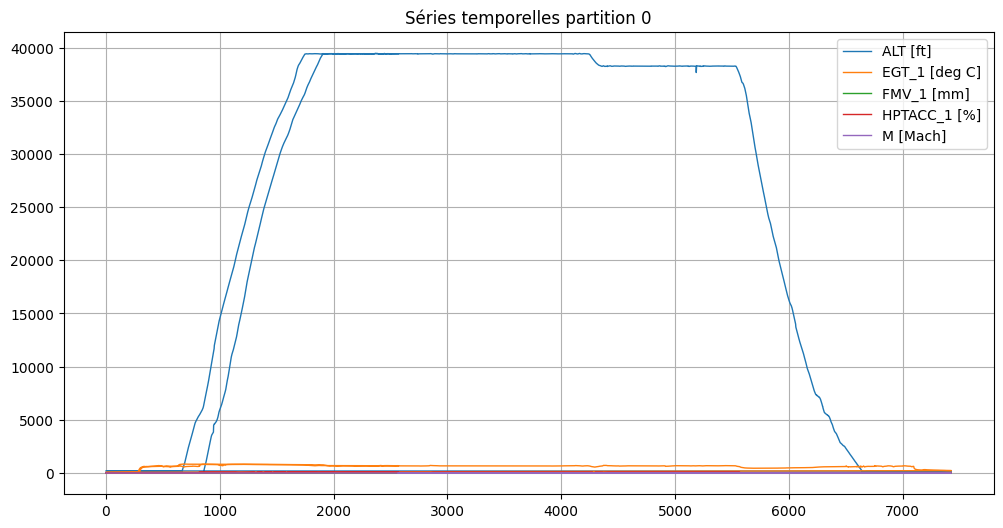

In [31]:
import matplotlib.pyplot as plt 

def tracer_serie_temporelle(ddf, numero_partition, colonnes, n_points = 10000):
    """
    Trace la série temporelle pour les colonnes spécifiées à partir d'une table donnée dans le fichier HDF5.
    
    Paramètres:
    - ddf : dask dataframe
    - numero_partition: Le numéro de la table à charger à partir du fichier HDF5.
    - colonnes: Une liste de colonnes à tracer.
    """
    try:
        # On charge uniquement la partition
        df = ddf.get_partition(numero_partition).head(n_points)
    except:
        print("❌ Numéro de partition invalide")
        return
    
    plt.figure(figsize=(12,6))
    for col in colonnes:
        if col in df.columns:
            plt.plot(df.index, df[col], label=col, linewidth=1)
        else:
            print(f"⚠️ Colonne absente : {col}")

    plt.title(f"Séries temporelles partition {numero_partition}")
    plt.legend()
    plt.grid()
    plt.show()
    


# Testing the function 
tracer_serie_temporelle(ddf, 0, ['ALT [ft]', 'EGT_1 [deg C]', 'FMV_1 [mm]', 'HPTACC_1 [%]', 'M [Mach]'])

**3. Calcul de la longueur des vols :**

In [32]:
def compter_lignes(df):
    return pd.DataFrame({'longueur': [len(df)]})

meta = pd.DataFrame({'longueur': pd.Series(dtype='int64')})

t0 = time.perf_counter()
longueurs = ddf_clean.map_partitions(compter_lignes,
                                     meta=meta).compute()
t1 = time.perf_counter()

print(longueurs)
print(f"⏱️ temps calcul = {t1-t0:.3f} s")

# Création dictionnaire
longueurs_vols = dict(zip(range(len(longueurs)), longueurs["longueur"]))


   longueur
0   1000000
0   1000000
0   1000000
0   1000000
0   1000000
0   1000000
0   1000000
0    574733
⏱️ temps calcul = 20.670 s


In [34]:
longueurs_vols

{0: 1000000,
 1: 1000000,
 2: 1000000,
 3: 1000000,
 4: 1000000,
 5: 1000000,
 6: 1000000,
 7: 574733}

In [33]:
vol_avec_longueur_max = max(longueurs_vols, key=longueurs_vols.get)
vol_avec_longueur_min = min(longueurs_vols, key=longueurs_vols.get)

print(f"{vol_avec_longueur_max} a la plus grande longueur de vol qui est =", longueurs_vols[vol_avec_longueur_max])
print(f"{vol_avec_longueur_min} a la plus petite longueur de vol qui est =", longueurs_vols[vol_avec_longueur_min])

0 a la plus grande longueur de vol qui est = 1000000
7 a la plus petite longueur de vol qui est = 574733


4. **Visualisation de la distribution de la longueur des vols :**

In [35]:
import plotly.express as px
import pandas as pd

df_box = pd.DataFrame({"vol": list(longueurs_vols.keys()),
                       "longueur": list(longueurs_vols.values())})

fig = px.box(df_box, y="longueur", title="Distribution des longueurs des vols")
fig.show()


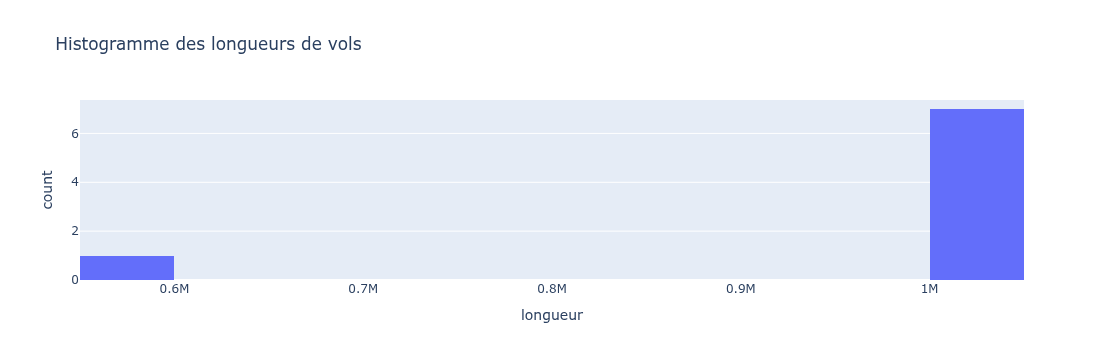

In [36]:
fig = px.histogram(df_box, x="longueur", nbins=20, title="Histogramme des longueurs de vols")
fig.show()